# Local Distortion in a Non-Isometric GW Match

This notebook generates `fig:gromov-nonisometric-distortion`.  After computing a hard correspondence from a mildly non-isometric GW coupling, we display the matched pairs and a white-to-black residual matrix
$$
    R_{i,i'} = \left|d_\mathcal X(x_i,x_{i'}) - d_\mathcal Y(y_{\sigma(i)},y_{\sigma(i')})\right| .
$$

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

from matplotlib.collections import LineCollection
import ot
from scipy.spatial.distance import cdist

rng = np.random.default_rng(2027)

NAME = "gromov-nonisometric-distortion"
out = figure_dir(NAME)

In [2]:
def base_shape(n=18):
    t = np.linspace(0, 1, n)
    x = 0.92 * np.cos(1.55 * np.pi * t) + 0.13 * t
    y = 0.74 * np.sin(1.55 * np.pi * t) - 0.28 * t
    q = np.column_stack([x, y])
    q += 0.014 * rng.normal(size=q.shape)
    return q


def rotate(q, a):
    c, s = np.cos(a), np.sin(a)
    R = np.array([[c, -s], [s, c]])
    return q @ R.T


def gw_plan(x, y):
    C1 = ot.dist(x, x)
    C2 = ot.dist(y, y)
    C1 /= max(C1.max(), 1e-12)
    C2 /= max(C2.max(), 1e-12)
    a = np.ones(len(x)) / len(x)
    b = np.ones(len(y)) / len(y)
    G0 = np.eye(len(x), len(y)) / len(x)
    T = ot.gromov.gromov_wasserstein(C1, C2, a, b, "square_loss", G0=G0, epsilon=1e-3, max_iter=500, tol=1e-10, verbose=False)
    return T, C1, C2


def draw_match(x, y, T, distort, filename):
    xd = x + np.array([-1.25, 0.0])
    yd = y + np.array([1.25, 0.0])
    pairs = [(i, int(np.argmax(T[i])), float(T[i].max())) for i in range(T.shape[0])]
    pts = np.vstack([xd, yd])
    xlim, ylim = padded_limits(pts, pad=0.085)
    fig, ax = plt.subplots(figsize=(2.72, 1.75))
    segs = []
    cols = []
    widths = []
    dd = distort / max(distort.max(), 1e-12)
    for i, j, _ in pairs:
        segs.append([xd[i], yd[j]])
        cols.append((*interp_color(float(0.12 + 0.78 * dd[i]), VIOLET, ORANGE), 0.34 + 0.42 * dd[i]))
        widths.append(0.18 + 0.92 * np.sqrt(dd[i] + 0.04))
    ax.add_collection(LineCollection(segs, colors=cols, linewidths=widths, zorder=1))
    draw_point_clouds(ax, xd, yd, base_size=DIRAC_MARKER_SIZE * 0.68)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.032)
    plt.close(fig)

x = base_shape(18)
t = np.linspace(0, 1, len(x))
y_base = rotate(x, 0.64)
y = np.empty_like(y_base)
y[:, 0] = 1.24 * y_base[:, 0] + 0.12 * np.sin(2.4 * np.pi * t)
y[:, 1] = 0.78 * y_base[:, 1] + 0.16 * y_base[:, 0] ** 2 - 0.10 * (t > 0.56) + 0.05 * np.cos(2 * np.pi * t)
T, C1, C2 = gw_plan(x, y)
match = np.argmax(T, axis=1)
res = np.abs(C1 - C2[np.ix_(match, match)])
point_residual = res.mean(axis=1)
draw_match(x, y, T, point_residual, "correspondence.pdf")

RESIDUAL_DISPLAY_VMAX = 0.75
fig, ax = plt.subplots(figsize=(1.75, 1.75))
ax.imshow(res, cmap="gray_r", interpolation="nearest", vmin=0.0, vmax=RESIDUAL_DISPLAY_VMAX)
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.75)
    sp.set_color("#000000")
save_pdf(fig, out / "distance-residual.pdf", pad_inches=0.032)
plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


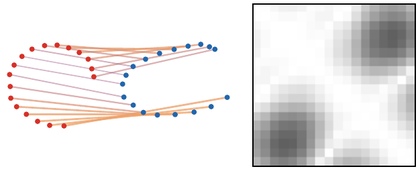

In [3]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/gromov-nonisometric-distortion.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/gromov-nonisometric-distortion.png")
display(Image(filename=str(_thumb)))
